In [ ]:
!pip install transformers datasets -q

In [ ]:
!pip install evaluate -q

In [ ]:
!pip install accelerate -q

In [ ]:
!pip install peft -q

In [ ]:
!pip install scikit-learn -q

# Прокинем либы, сиды

In [ ]:
import torch
import numpy as np
import random
import time
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import get_peft_model, LoraConfig, TaskType
import evaluate
import matplotlib.pyplot as plt

In [ ]:
def set_seed(seed=4221):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(4221)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Загрузка датасета + модель

Я выбрал проверять иронию с твиттера. Почему так? Звучит хайпово если честно.
https://huggingface.co/datasets/cardiffnlp/tweet_eval

In [ ]:
dataset = load_dataset("tweet_eval", "irony")

train_dataset = dataset["train"]
eval_dataset = dataset["test"]

print(f"Пример текста {train_dataset[0]['text']}")
print(f"Label (0 = не ирония, 1 = рония) {train_dataset[0]['label']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Пример текста seeing ppl walking w/ crutches makes me really excited for the next 3 weeks of my life
Label (0 = не ирония, 1 = рония) 1


Модель я выбрала дистиллят от BERT, так как BERT крутые модели, то почему и не взять ее. В коллабе влезает спокойно и качество должно быть хорошим.

И я взял uncased, так как оно приводит все к нижнему регистру. Банально просто проще будет возиться с текстом, хотя капс явно может помочь определять эмоциональный окрас и т.д

In [ ]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(examples):
    return tokenizer(examples["text"], truncation=True, padding=False, max_length=100)

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_eval = eval_dataset.map(preprocess_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Небольшой EDA + метрики

Посмотрим на длину твиттов

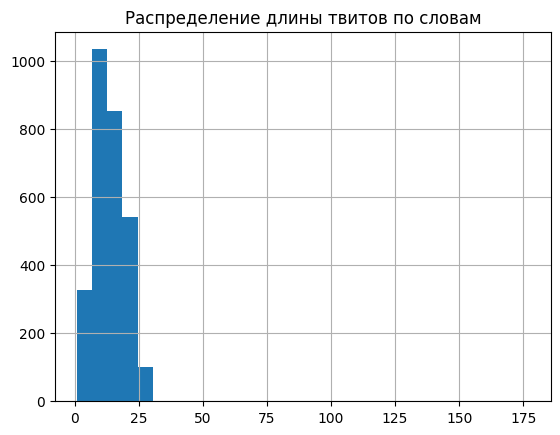

In [ ]:
df_train = dataset['train'].to_pandas()

seq_len = [len(i.split()) for i in df_train['text']]
pd.Series(seq_len).hist(bins=30)
plt.title('Распределение длины твитов по словам')
plt.show()

Ну какие то короткие твитты, ну и ладно.

Вообще у меня в `preprocess_function` стоит макс длина токена 100 и нет паддинга. Но зато есть `DataCollatorWithPadding`, он будет динамически делать паддинг в батче, поэтому много нулей не будет везде

Ну и посмотрим на распределение классов

Баланс классов
label
1    1445
0    1417
Name: count, dtype: int64


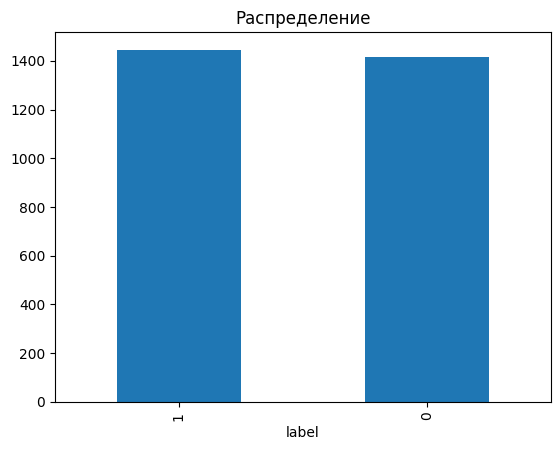

In [ ]:
class_counts = df_train['label'].value_counts()
print("Баланс классов")
print(class_counts)

class_counts.plot(kind='bar', title='Распределение')
plt.show()

УРА!!!! Наконец то я буду делать лабу с балансированными классами

По поводу метрик тут ничего особенного. Базовый accuracy (хотя все же мне метрика не нравится, но у нас класс в балансе, то почему бы и нет) и F1

In [ ]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"]
    }

# Базовая ф-ция инициализации для всех

Все по БАЗЕ, так сказать. батч 32, lr 2e-5, с регуляризацией 0.01 и 10 эпох. И финальный штрих использование лучшей модели! Решил в этой лабораторной так сделать, ради разнообразия, хотя можно и раннюю остановку сделать. Сохраняем по расчетам `val_loss`, чтобы не сохранять переобученную

Оптимизатор AdamW, я его не указал, но как я понял он сразу из коробки по умолчанию приписывается из `TrainingArguments`

In [ ]:
def get_base_model():
    return AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=2
    ).to(device)

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    seed=4221,
    report_to="none"
)

# Как было без обучения

Просто посмотрим как работает модель сразу из коробки

In [ ]:
model_asis = get_base_model()

trainer_eval = Trainer(
    model=model_asis,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

metrics_asis = trainer_eval.evaluate()
print(f"Accuracy: {metrics_asis['eval_accuracy']:.4f}")
print(f"F1-score: {metrics_asis['eval_f1']:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Accuracy: 0.5115
F1-score: 0.5119


Ну тут ничего неожиданного, 50/50 угадываем. У нас классификатор инициализируется случайными значениями и не обучен под определение иронии

# Дообучение

Просто учим модель, без смс и регистрации

In [ ]:
model_full = get_base_model()

trainer_full = Trainer(
    model=model_full,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_full.train()
full_time = time.time() - start_time

metrics_full = trainer_full.evaluate()

print(f"Train time {full_time:.2f} сек ({full_time/60:.2f} мин)")
print(f"Accuracy {metrics_full['eval_accuracy']:.4f}")
print(f"F1 {metrics_full['eval_f1']:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.626301,0.635204,0.637434
2,0.621400,0.634735,0.677296,0.680496
3,0.403200,0.844910,0.681122,0.684392
4,0.403200,1.445067,0.677296,0.679878
5,0.191300,1.685447,0.670918,0.674362
6,0.076300,1.828596,0.705357,0.707051
7,0.037800,1.953893,0.686224,0.689259
8,0.037800,2.091670,0.679847,0.683288
9,0.018200,2.128090,0.687500,0.690830
10,0.013100,2.174383,0.686224,0.689591


Train time 410.56 сек (6.84 мин)
Accuracy 0.6352
F1 0.6374


Ну метрики стали выше, теперь это не просто угадывание. Но есть так сказать нюансик. `Val_loss` начал расти с 2 эпохи. Получилось только эпоха 1 лучшей была :/

ПРИВЕТ ПЕРЕОБУЧЕНИЕ

# Дообучение только классификатора

Заморозили все, кроме головы, он же классификатор. Просто не считаем градиенты везде кроме места где `classifier`. Ну и да, учим всего 0.88% параметров от всех!

In [ ]:
model_lp = get_base_model()

for name, param in model_lp.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable_params = sum(p.numel() for p in model_lp.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model_lp.parameters())
print(f"Обучаемых параметров {trainable_params} из всех {all_params} ({trainable_params/all_params:.2%})")

trainer_lp = Trainer(
    model=model_lp,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_lp.train()
lp_time = time.time() - start_time

metrics_lp = trainer_lp.evaluate()

print(f"Train time {lp_time:.2f} сек ({lp_time/60:.2f} мин)")
print(f"Accuracy {metrics_lp['eval_accuracy']:.4f}")
print(f"F1 {metrics_lp['eval_f1']:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Обучаемых параметров 592130 из всех 66955010 (0.88%)


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.697904,0.521684,0.519315
2,0.682200,0.682676,0.568878,0.554903
3,0.660900,0.689171,0.575255,0.577999
4,0.660900,0.681803,0.585459,0.584110
5,0.657100,0.681837,0.576531,0.579193
6,0.644100,0.681767,0.571429,0.575823
7,0.646500,0.679119,0.571429,0.575769
8,0.646500,0.674929,0.576531,0.580469
9,0.641800,0.676778,0.575255,0.579753
10,0.637500,0.675925,0.576531,0.580999


Train time 172.03 сек (2.87 мин)
Accuracy 0.5765
F1 0.5805


Ну по сравнению с сырой моделью мы получили прирост в метриках неплохой, при этом обучив быстрее чем полное дообучение

# LoRa

Здесь ничего сверх оригинального

Увеличил ранг матрицы чтобы лучше запоминать сложные паттерны

и расширил `target_modules`, чтобы он смотрел во все линейный слои

In [ ]:
model_lora = get_base_model()

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=32,
    lora_alpha=64,
    lora_dropout=0.1,
    target_modules=["q_lin", "v_lin", "k_lin", "out_lin", "lin1", "lin2"]
)

model_lora = get_peft_model(model_lora, peft_config)

model_lora.print_trainable_parameters()

trainer_lora = Trainer(
    model=model_lora,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

start_time = time.time()
trainer_lora.train()
lora_time = time.time() - start_time

metrics_lora = trainer_lora.evaluate()

print(f"Train time {lora_time:.2f} сек")
print(f"Accuracy {metrics_lora['eval_accuracy']:.4f}")
print(f"F1 {metrics_lora['eval_f1']:.4f}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 3,246,338 || all params: 70,201,348 || trainable%: 4.6243


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.679577,0.589286,0.592070
2,0.663500,0.652553,0.616071,0.619246
3,0.588100,0.639713,0.609694,0.613866
4,0.588100,0.653370,0.633929,0.637710
5,0.547000,0.663274,0.632653,0.636559
6,0.504800,0.667945,0.650510,0.653890
7,0.486400,0.708874,0.632653,0.636382
8,0.486400,0.702038,0.651786,0.655538
9,0.462300,0.721969,0.645408,0.649199
10,0.436000,0.719844,0.647959,0.651738


Train time 155.41 сек
Accuracy 0.6097
F1 0.6139


Взяли лучшее из двух миров. Обучились быстрее чем полное дообучене и лучше по метрикам чем обучение только классификатора

# Сравнение

In [ ]:
results_df = pd.DataFrame({
    "Method": ["As-Is", "Full Fine-Tuning", "Linear Probing", "LoRA"],
    "Accuracy": [
        metrics_asis['eval_accuracy'],
        metrics_full['eval_accuracy'],
        metrics_lp['eval_accuracy'],
        metrics_lora['eval_accuracy']
    ],
    "F1-Score": [
        metrics_asis['eval_f1'],
        metrics_full['eval_f1'],
        metrics_lp['eval_f1'],
        metrics_lora['eval_f1']
    ],
    "Loss": [
        metrics_asis['eval_loss'],
        metrics_full['eval_loss'],
        metrics_lp['eval_loss'],
        metrics_lora['eval_loss']
    ],
    "Time (s)": [
        0,
        full_time,
        lp_time,
        lora_time
    ]
})

print(results_df.round(4).to_markdown(index=False))

| Method           |   Accuracy |   F1-Score |   Loss |   Time (s) |
|:-----------------|-----------:|-----------:|-------:|-----------:|
| As-Is            |     0.5115 |     0.5119 | 0.6907 |      0     |
| Full Fine-Tuning |     0.6352 |     0.6374 | 0.6263 |    410.56  |
| Linear Probing   |     0.5765 |     0.5805 | 0.6749 |    172.031 |
| LoRA             |     0.6097 |     0.6139 | 0.6397 |    155.411 |


Получили закономерный результат. LoRa все же выгоднее смотрится чем остальные методы тут

Вообще думал смогу получить более высокие метрики, но видимо из за того что БЕРТ учился на википедии, где 0 иронии, ему сложно понять твиттерских ребят

Но все же основная цель посмотреть и сравнить методы

и LoRa как по мне интереснее, потому что х2 быстрее от полного дообучения, да и разница в метриках небольшая.